# Problem B: Solve Pressure Field in 2D Heterogeneous Porous Media

Consider a square domain $\Omega = [0,1]^2$ representing a heterogeneous porous medium composed of two distinct material phases with significantly different permeabilities, for instance, high-permeability sandstone inclusions embedded in a low-permeability mudstone matrix. Such heterogeneous structures arise frequently in subsurface flow engineering, including groundwater modeling, hydrocarbon reservoir simulation, and fuel cell design. Near the interface between the two phases, the pressure gradient exhibits sharp transitions, making this a classical benchmark for testing the robustness of PDE solvers under non-smooth coefficients.

The permeability field $\mu(x)$ is defined as:

$$
\mu(x) =
\begin{cases}
\mu_1 = 10, & x \in \Omega_1 \quad \text{(high-permeability phase, e.g., sandstone)} \\
\mu_2 = 2,  & x \in \Omega_2 \quad \text{(low-permeability phase, e.g., mudstone)}
\end{cases}
$$

The specific two-phase microstructure (i.e., the geometric distribution of $\Omega_1$ and $\Omega_2$) is provided in the dataset. The pressure field $u(x)$ satisfies the following Darcy flow equation:

$$
-\nabla \cdot \left(\mu(x)\,\nabla u\right) = f, \quad x \in \Omega \tag{1}
$$

where
- $u(x):$ pressure field in the porous medium
- $\mu(x):$ spatially varying permeability field
- $f = 0:$ source term (no internal source/sink)
- $\Omega = [0,1]^2:$ square computational domain

The boundary conditions are prescribed as follows, driving fluid flow from the high-pressure inlet on the left to the low-pressure outlet on the right:

$$
g_D(x) =
\begin{cases}
1, & x_1 = 0 \quad \text{(left boundary, high-pressure inlet)} \\
0, & x_1 = 1 \quad \text{(right boundary, low-pressure outlet)} \\
\text{linear interpolation}, & x_2 = 0 \text{ or } 1 \quad \text{(top and bottom boundaries)}
\end{cases}
$$

## Task: Solve the pressure field $u(x)$

In this task, the permeability field $\mu(x)$ is provided as a $128 \times 128$ pixel matrix — that is, the domain is subdivided into $128 \times 128$ cells, each with a constant permeability value. Using this permeability field, apply a suitable method introduced in the lecture to solve for the pressure field $u(x)$ in the heterogeneous porous medium.

### The Goals
- Please select a suitable deep learning method for solving this forward problem to compute the pressure field $u(x)$, and explain the reason for using it.
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on the testing dataset) at each training epoch and plot the `Error vs. epoch` curve (and report the final error). The $L^2$ relative error between the prediction $u_\text{pred}$ and the reference $u_\text{true}$ is defined as follows:

$$
\text{error} = \sqrt{\frac{\sum_i^n \left| u_\text{pred}(x_i) - u_\text{true}(x_i) \right|^2}{\sum_i^n \left| u_\text{true}(x_i) \right|^2}}
$$

- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with `matplotlib`.

### Dataset

The permeability field and the reference solution are provided in the dataset `ProblemB_dataset.h5`:

- `mu_field`: the permeability field $\mu(x)$, represented as a $128 \times 128$ pixel matrix, where each cell has a constant permeability value (available for training)
- `x_test`: the locations where the reference solution is evaluated (Used for computing error and should **not** be used for training)
- `u_test`: the reference pressure field values (used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

In [1]:
import os,time
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import numpy as np
import torch
import h5py
import matplotlib.pyplot as  plt

#The testing dataset

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with h5py.File('ProblemB_dataset.h5', 'r') as f:
    x_test = torch.tensor(np.array(f['x_test']), dtype=torch.float32)
    u_test = torch.tensor(np.array(f['u_test']).reshape(-1, 1), dtype=torch.float32)
    mu_field = torch.tensor(np.array(f['mu_field']), dtype=torch.float32)
print('x_test:', x_test.shape, 'u_test:', u_test.shape, 'mu_field:', mu_field.shape)
#
def fun_mu(x, mu=mu_field, resolution=128):
    '''The material property field (get values of material field on any given position x)
    Input:
        x: size(N, 2)
    '''
    mu = mu.reshape(1, -1).to(x)
    delta = 1. / (resolution - 1)
    x_loc = torch.floor(x[..., 0] / delta + 0.5).int()
    y_loc = torch.floor(x[..., 1] / delta + 0.5).int()
    loc = (y_loc * resolution + x_loc).long().clamp(0, resolution**2 - 1)
    return mu[torch.arange(mu.shape[0]).unsqueeze(1), loc].T

mu = fun_mu(x_test)

#
#fig, axes = plt.subplots(1, 2, figsize=(10,4))
#
#cntr = axes[0].imshow(mu.reshape(128,128), origin='lower')
#axes[0].set_title(r'The permeability field $\mu(x)$')
#plt.colorbar(cntr)
#
#cntr = axes[1].contourf(x_test[:,0].reshape(128, 128), x_test[:,1].reshape(128, 128), u_test, levels=50)
#axes[1].set_xlabel('x')
#axes[1].set_ylabel('y')
#xes[1].set_title(r'The true pressure field $u(x)$')
#plt.colorbar(cntr)
#plt.show()

x_test: torch.Size([16384, 2]) u_test: torch.Size([16384, 1]) mu_field: torch.Size([128, 128])


In [2]:
#PINN Model
class PINN2D(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, 128), torch.nn.Tanh(),
            torch.nn.Linear(128, 128), torch.nn.Tanh(),
            torch.nn.Linear(128, 128), torch.nn.Tanh(),
            torch.nn.Linear(128, 1))
    def forward(self, x): return self.net(x)

model = PINN2D().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [3]:
#Boundary Value 
def boundary_points(n):
    """FIX 2: sample points uniformly ON the four edges."""
    t = torch.rand(n, device=device)
    side = torch.randint(0, 4, (n,), device=device)
    x = torch.zeros(n, 2, device=device)
    x[:, 0] = torch.where(side == 0, torch.zeros_like(t),
              torch.where(side == 1, torch.ones_like(t), t))
    x[:, 1] = torch.where(side == 2, torch.zeros_like(t),
              torch.where(side == 3, torch.ones_like(t), t))
    return x

In [4]:
#Boundary Loss
def boundary_u(x):
    x1, x2 = x[:, 0], x[:, 1]
    u = torch.zeros_like(x1)
    u = torch.where(x1 == 0, torch.ones_like(u), u)   # left inlet u=1
    u = torch.where(x1 == 1, torch.zeros_like(u), u)  # right outlet u=0
    edge_tb = ((x2 == 0) | (x2 == 1)) & (x1 > 0) & (x1 < 1)
    u = torch.where(edge_tb, 1.0 - x1, u)             # FIX 3
    return u.unsqueeze(1)

In [5]:
#Residual loss
def pde_residual(x):
    x = x.clone().requires_grad_(True)
    u = model(x)
    g = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    ux, uy = g[:, 0:1], g[:, 1:2]
    uxx = torch.autograd.grad(ux, x, torch.ones_like(ux), create_graph=True)[0][:, 0:1]
    uyy = torch.autograd.grad(uy, x, torch.ones_like(uy), create_graph=True)[0][:, 1:2]
    mu = fun_mu(x.detach()).to(x)
    # mu is piecewise constant -> grad(mu)=0 a.e., residual = -mu * laplacian(u)
    return -(mu * (uxx + uyy))

In [6]:
#Training 

epochs = 5000
errors = []
x_test_d, u_test_d = x_test.to(device), u_test.to(device)
t0 = time.time()
for ep in range(epochs):
    optimizer.zero_grad()
    x_col = torch.rand((3000, 2), device=device)
    xb = boundary_points(800)
    L_pde = (pde_residual(x_col) ** 2).mean()
    L_bc = ((model(xb) - boundary_u(xb)) ** 2).mean()
    loss = L_pde + 10 * L_bc
    loss.backward(); optimizer.step()
    with torch.no_grad():
        up = model(x_test_d)
        err = torch.sqrt(((up - u_test_d) ** 2).sum() / (u_test_d ** 2).sum()).item()
        errors.append(err)
    if ep % 250 == 0:
        print(f"ep {ep}  loss {loss.item():.4e}  err {err:.4f}  ({time.time()-t0:.0f}s)")

print("Final relative L2 error:", errors[-1])

C:\Users\abhia\anaconda3\envs\torch311\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


ep 0  loss 3.9049e+00  err 0.5868  (1s)
ep 250  loss 1.7082e-03  err 0.0895  (3s)
ep 500  loss 9.7183e-04  err 0.0910  (5s)
ep 750  loss 6.6795e-04  err 0.0884  (8s)
ep 1000  loss 3.5850e-04  err 0.0872  (10s)
ep 1250  loss 2.8354e-04  err 0.0886  (13s)
ep 1500  loss 7.4091e-03  err 0.1084  (15s)
ep 1750  loss 6.7247e-05  err 0.0888  (17s)
ep 2000  loss 4.3534e-05  err 0.0885  (20s)
ep 2250  loss 3.8395e-05  err 0.0875  (22s)
ep 2500  loss 2.0070e-05  err 0.0883  (25s)
ep 2750  loss 3.1720e-05  err 0.0874  (27s)
ep 3000  loss 3.7527e-03  err 0.0763  (29s)
ep 3250  loss 4.9332e-05  err 0.0889  (31s)
ep 3500  loss 1.2805e-05  err 0.0885  (34s)
ep 3750  loss 1.4732e-04  err 0.0905  (36s)
ep 4000  loss 1.5463e-05  err 0.0879  (37s)
ep 4250  loss 3.7815e-03  err 0.0944  (39s)
ep 4500  loss 1.4491e-05  err 0.0885  (41s)
ep 4750  loss 1.6806e-05  err 0.0889  (43s)
Final relative L2 error: 0.08938883244991302


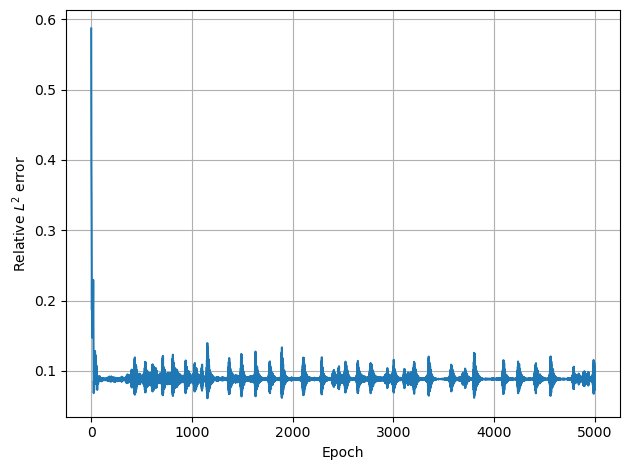

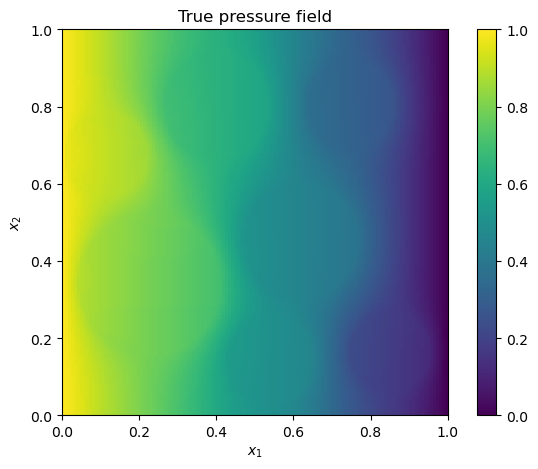

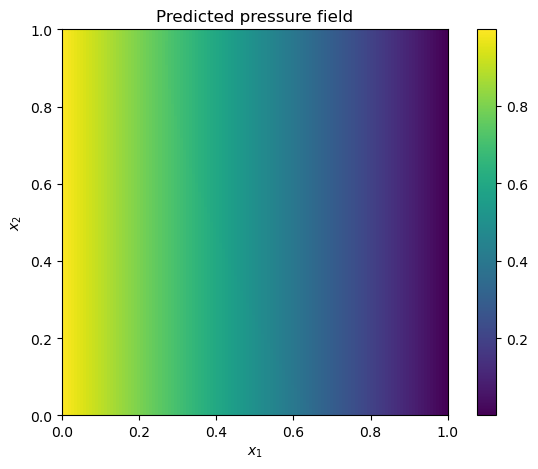

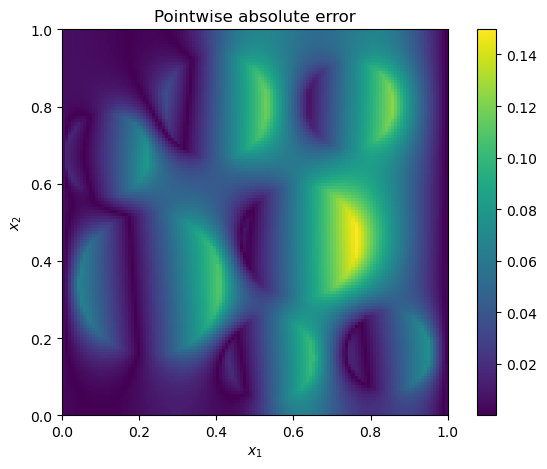

In [7]:
#Plots

plt.figure(); plt.plot(errors)
plt.xlabel("Epoch"); plt.ylabel("Relative $L^2$ error"); plt.grid(True)
plt.tight_layout(); plt.savefig('B_error_vs_epoch.png', dpi=150); plt.show()

u_pred = model(x_test_d).detach().cpu().numpy().reshape(128, 128)
u_true = u_test.numpy().reshape(128, 128)
for arr, name, title in [(u_true, 'B_u_true', 'True pressure field'),
                         (u_pred, 'B_u_pred', 'Predicted pressure field'),
                         (np.abs(u_pred - u_true), 'B_u_abs_err', 'Pointwise absolute error')]:
    plt.figure()
    im = plt.imshow(arr, origin='lower', extent=[0, 1, 0, 1])
    plt.colorbar(im); plt.title(title); plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
    plt.tight_layout(); plt.savefig(f'{name}.png', dpi=150); plt.show()